
# Forecast Visualization (Top Revenue / Top Volume Series)

This notebook visualizes your reconciled forecasting outputs:
- **TFT** 12‑month forecast with uncertainty bands (q10–q90, q50)
- **LightGBM baseline** validation forecasts (if actuals exist)
- **History** (ERP) for context and trend comparison

## What you’ll get
- Portfolio‑level dashboards (top series, trend distribution, monthly totals)
- Per‑series deep dive plots (history + forecast + uncertainty)
- Error distributions for the baseline model (MAE/WAPE) on top series

> ✅ Designed around your decision metric: **best performance on TOP revenue / TOP volume series**.



## Suggested metrics to show in the visualizations

### A) Accuracy / performance (when actuals exist)
These help you decide which model is best on **top revenue/top volume** series:
- **MAE** (mean absolute error)
- **WAPE** (weighted absolute percentage error = sum(|err|)/sum(actual)) — strong for top‑volume focus
- **Bias** (mean error = mean(pred − actual))
- **Hit rate on zero** (how often a model correctly predicts 0 when actual is 0)
- **Non‑zero MAE/WAPE** (metrics only on months where actual > 0)

### B) Forecast quality / risk
Especially useful for TFT (quantiles):
- **Prediction interval width** (q90 − q10) and width relative to q50
- **Coverage** (if you also generate TFT backtest quantiles): % actuals within [q10, q90]
- **Volatility / stability**: std(q50) or coefficient of variation over the forecast horizon

### C) Business impact
These align with decision‑making and prioritization:
- **Contribution to total forecast** (% of total q50 across top series)
- **Top‑N monthly totals** (sum forecast by month)
- **Trend flag**: stable / increasing / decreasing
- **Peak month / peak quarter** (when forecast is highest)

This notebook implements many of these out‑of‑the‑box.


## 0) Install / import (run once)

If you get missing library errors, install these:
```bash
pip install pandas numpy matplotlib seaborn openpyxl
```


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


## 1) Input paths

Set the paths to your files. Defaults assume you run this notebook from the same folder as the outputs.


In [2]:

# ---- Inputs ----
HISTORY_CSV = "data/training/training_data_final.csv"  # dense monthly history
TFT_FORECAST_CSV = "outputs/tft_forecast_12m.csv"    # TFT future forecast (q10/q50/q90...)
LGBM_BASELINE_CSV = "outputs/baseline_lightgbm_forecast_results.csv"  # LGBM validation output (has y_qty)

# Optional: reconciliation v2 outputs (if you want to use them directly)
SUMMARY_V2_CSV = "reconcile_outputs/reconcile_series_summary_v2.csv"              # created by reconcile v2
TFT_TOP_V2_CSV = "reconcile_outputs/reconcile_top_series_tft_forecasts_v2.csv"    # created by reconcile v2
LGBM_TOP_V2_CSV = "reconcile_outputs/reconcile_top_series_lgbm_validation_v2.csv"  # created by reconcile v2

# ---- Config ----
TOP_N_REVENUE = 200
TOP_N_QTY = 200
TREND_PCT_THRESHOLD = 0.10
TREND_MIN_MEAN = 1e-6

# Plot controls
SHOW_TOP_N = 20  # for bar charts


## 2) Load data

We’ll load:
- history (last 12 months used for top ranking)
- TFT forecast
- LGBM baseline (validation)

If `reconcile_*_v2.csv` files exist, we’ll use them for convenience.


In [3]:

from pathlib import Path

# Helper

def safe_read_csv(path, **kwargs):
    p = Path(path)
    if not p.exists():
        return None
    return pd.read_csv(p, **kwargs)

# Load TFT
_tft = safe_read_csv(TFT_FORECAST_CSV, parse_dates=["Date"], low_memory=False)
if _tft is None:
    raise FileNotFoundError(f"Missing {TFT_FORECAST_CSV}")

forecast_start = _tft["Date"].min()
forecast_end = _tft["Date"].max()

print("TFT rows:", len(_tft), "| series:", _tft['series_id'].nunique(), "| forecast:", forecast_start.date(), "→", forecast_end.date())

# Load history minimal
hist_cols = ["customer_id","product_id","customer_name","product_group","product_name","Date","ordered_qty","order_amount"]
hist = safe_read_csv(HISTORY_CSV, usecols=hist_cols, parse_dates=["Date"], low_memory=False)
if hist is None:
    raise FileNotFoundError(f"Missing {HISTORY_CSV}")

hist["series_id"] = hist["customer_id"].astype(str) + "_" + hist["product_id"].astype(str)
print("History rows:", len(hist), "| series:", hist['series_id'].nunique(), "| range:", hist['Date'].min().date(), "→", hist['Date'].max().date())

# Load LGBM (baseline validation)
# Use only a few columns to keep memory low
lgbm_header = pd.read_csv(LGBM_BASELINE_CSV, nrows=0)
cols = lgbm_header.columns.tolist()
use = [c for c in ["customer_id","product_id","customer_name","product_group","product_name","Date","forecast_qty","y_qty"] if c in cols]
_lgbm = safe_read_csv(LGBM_BASELINE_CSV, usecols=use, parse_dates=["Date"], low_memory=False)
if _lgbm is not None:
    _lgbm["series_id"] = _lgbm["customer_id"].astype(str) + "_" + _lgbm["product_id"].astype(str)
    print("LGBM rows:", len(_lgbm), "| series:", _lgbm['series_id'].nunique(), "| range:", _lgbm['Date'].min().date(), "→", _lgbm['Date'].max().date())
else:
    print("LGBM file not found or could not be loaded.")

# Prefer reconcile v2 outputs if present
summary_v2 = safe_read_csv(SUMMARY_V2_CSV, low_memory=False)
tft_top_v2 = safe_read_csv(TFT_TOP_V2_CSV, parse_dates=["Date"], low_memory=False)
lgbm_top_v2 = safe_read_csv(LGBM_TOP_V2_CSV, parse_dates=["Date"], low_memory=False)

if summary_v2 is not None and tft_top_v2 is not None:
    print("Using reconcile v2 outputs.")
else:
    print("Reconcile v2 outputs not found — will compute TOP series inside this notebook.")


TFT rows: 33372 | series: 2781 | forecast: 2024-12-01 → 2025-11-01
History rows: 330939 | series: 2781 | range: 2015-01-01 → 2024-11-01
LGBM rows: 33408 | series: 2781 | range: 2018-01-01 → 2024-11-01
Using reconcile v2 outputs.


## 3) Build TOP series list (by last 12 months revenue + volume)

This replicates the decision metric used in reconciliation.


In [4]:

# Define the last-12-month window BEFORE forecast_start
hist_window_start = forecast_start - pd.DateOffset(months=12)
hist_window_end = forecast_start - pd.DateOffset(months=1)

hist12 = hist[(hist["Date"] >= hist_window_start) & (hist["Date"] <= hist_window_end)].copy()

agg = hist12.groupby("series_id", as_index=False).agg(
    hist_revenue=("order_amount", "sum"),
    hist_qty=("ordered_qty", "sum"),
    customer_id=("customer_id", "first"),
    product_id=("product_id", "first"),
    customer_name=("customer_name", "first"),
    product_group=("product_group", "first"),
    product_name=("product_name", "first"),
)

agg["rev_rank"] = agg["hist_revenue"].rank(method="first", ascending=False)
agg["qty_rank"] = agg["hist_qty"].rank(method="first", ascending=False)
agg["is_top_revenue"] = agg["rev_rank"] <= TOP_N_REVENUE
agg["is_top_qty"] = agg["qty_rank"] <= TOP_N_QTY
agg["is_top_series"] = agg["is_top_revenue"] | agg["is_top_qty"]

top_series = agg[agg["is_top_series"]].copy()
print("Top series:", len(top_series), "(union of Top", TOP_N_REVENUE, "revenue + Top", TOP_N_QTY, "qty)")

# Filter TFT to TOP series
if tft_top_v2 is None:
    tft_top = _tft.merge(top_series[["series_id"]], on="series_id", how="inner").copy()
    # add Year/Month
    tft_top["Year"] = tft_top["Date"].dt.year
    tft_top["Month"] = tft_top["Date"].dt.month
else:
    tft_top = tft_top_v2.copy()

# Filter LGBM to TOP series (optional)
if lgbm_top_v2 is None and _lgbm is not None:
    lgbm_top = _lgbm.merge(top_series[["series_id"]], on="series_id", how="inner").copy()
    lgbm_top["forecast_qty"] = lgbm_top["forecast_qty"].clip(lower=0)
    lgbm_top["Year"] = lgbm_top["Date"].dt.year
    lgbm_top["Month"] = lgbm_top["Date"].dt.month
else:
    lgbm_top = lgbm_top_v2.copy() if lgbm_top_v2 is not None else None

# Summary
print("TFT top rows:", len(tft_top), "| series:", tft_top['series_id'].nunique())
if lgbm_top is not None:
    print("LGBM top rows:", len(lgbm_top), "| series:", lgbm_top['series_id'].nunique())


Top series: 255 (union of Top 200 revenue + Top 200 qty)
TFT top rows: 3084 | series: 257
LGBM top rows: 3108 | series: 257


## 4) Predicted Quantity — Top Contributors (12M)


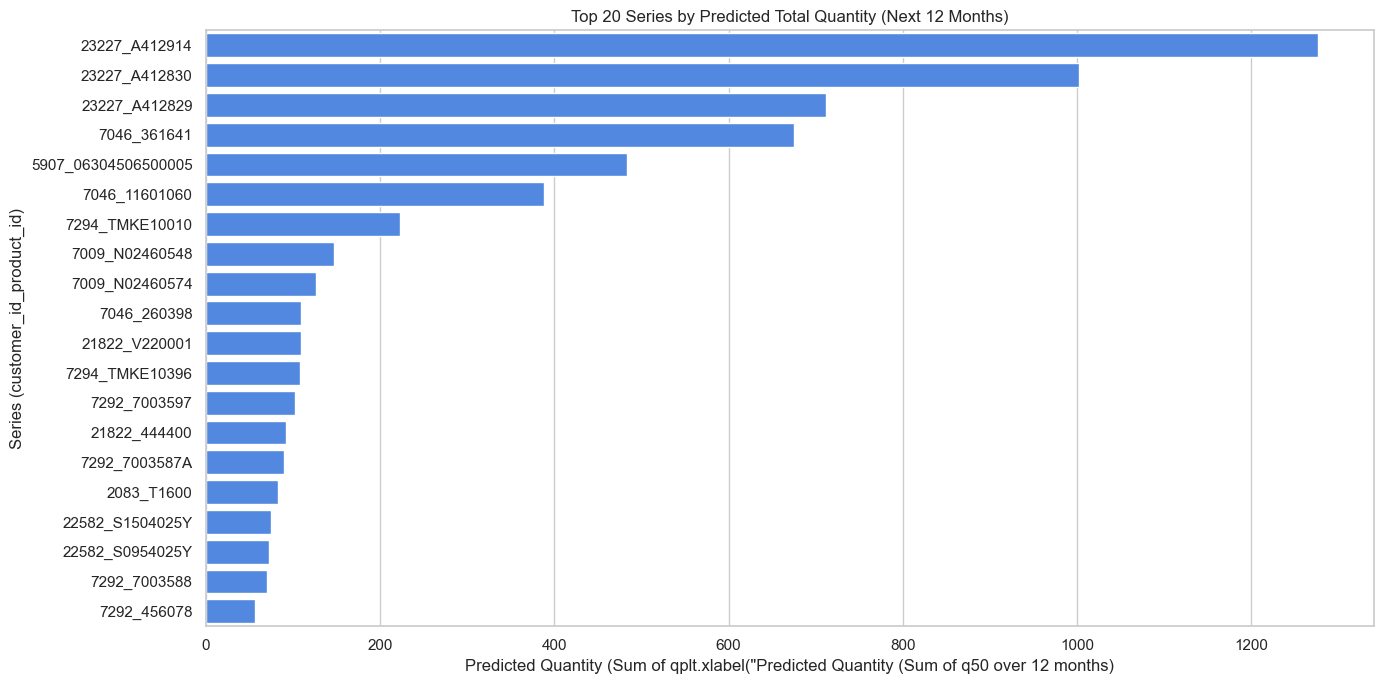

In [5]:

# ==========================================================
# 4.0) Predicted Quantity (12M) — Top Contributors
# Uses new columns added to Series_Summary in reconciliation notebook (05)
# ==========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Prefer reconcile summary if present (created by Notebook 05)
if summary_v2 is not None:
    summary_plot = summary_v2.copy()
else:
    # Fallback: if reconcile summary isn't available, compute pred_qty_total_12m from TFT top
    # (q50 is the point forecast)
    summary_plot = top_series.copy()
    if "q50" not in tft_top.columns:
        raise ValueError("TFT file does not contain q50. Cannot compute predicted totals.")
    pred_agg = (
        tft_top.groupby("series_id", as_index=False)
               .agg(pred_qty_total_12m=("q50", "sum"))
    )
    summary_plot = summary_plot.merge(pred_agg, on="series_id", how="left")

# Ensure the column exists (from Notebook 05 changes)
if "pred_qty_total_12m" not in summary_plot.columns:
    raise ValueError(
        "pred_qty_total_12m not found in Series_Summary. "
        "Run Notebook 05 after adding the merge code, then rerun Notebook 06."
    )

# Pick top K for chart (use SHOW_TOP_N from your notebook config if available)
TOPK = SHOW_TOP_N if "SHOW_TOP_N" in globals() else 20

plot_df = (
    summary_plot.sort_values("pred_qty_total_12m", ascending=False)
                .head(TOPK)
                .copy()
)

# Make a readable label
plot_df["label"] = plot_df["customer_id"].astype(str) + "_" + plot_df["product_id"].astype(str)

plt.figure(figsize=(14, 7))
sns.barplot(data=plot_df, y="label", x="pred_qty_total_12m", color="#3b82f6")
plt.title(f"Top {TOPK} Series by Predicted Total Quantity (Next 12 Months)")

plt.xlabel('Predicted Quantity (Sum of qplt.xlabel("Predicted Quantity (Sum of q50 over 12 months)')
plt.ylabel('Series (customer_id_product_id)')
plt.tight_layout()

## 5) Portfolio dashboards

- Trend distribution
- Total forecast by month (top series)
- Top contributors by historical revenue/volume


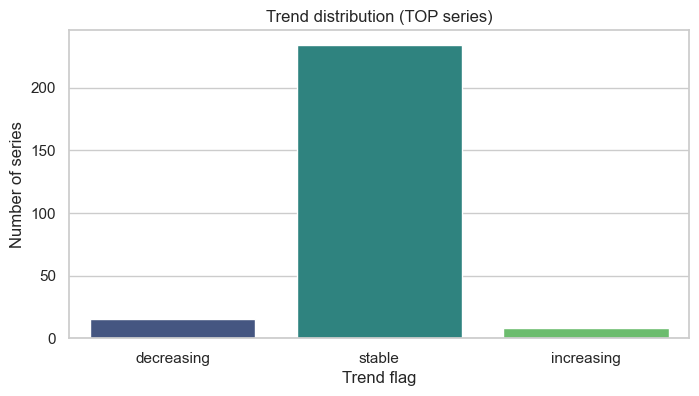

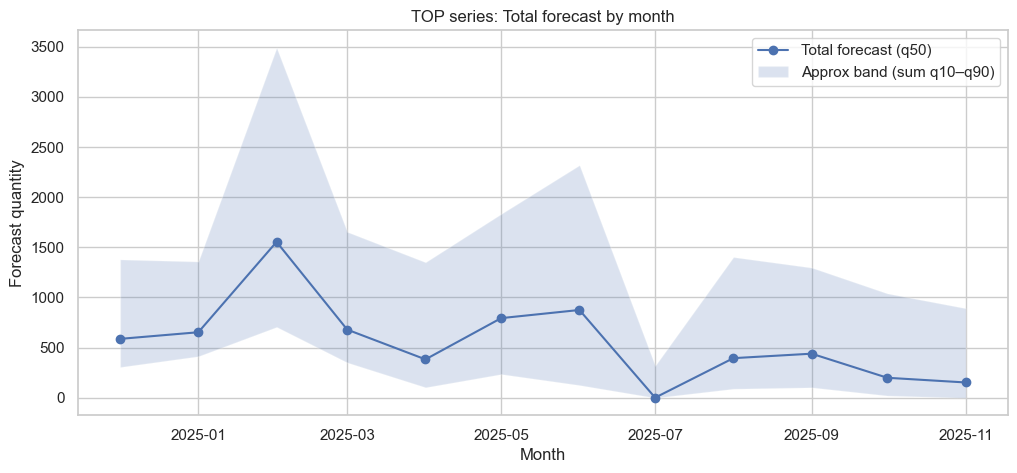

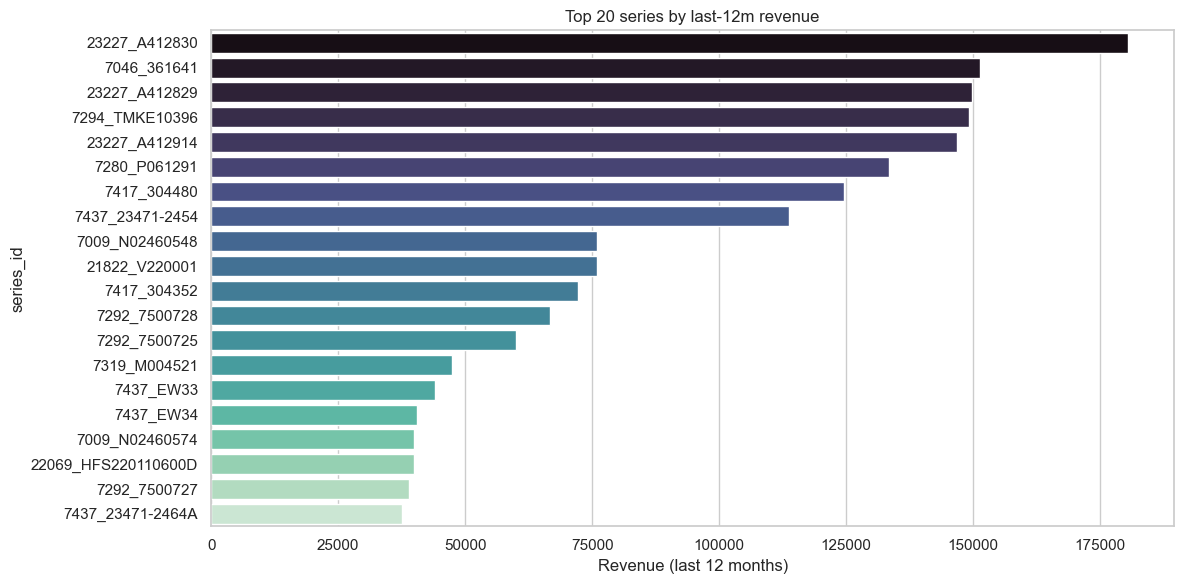

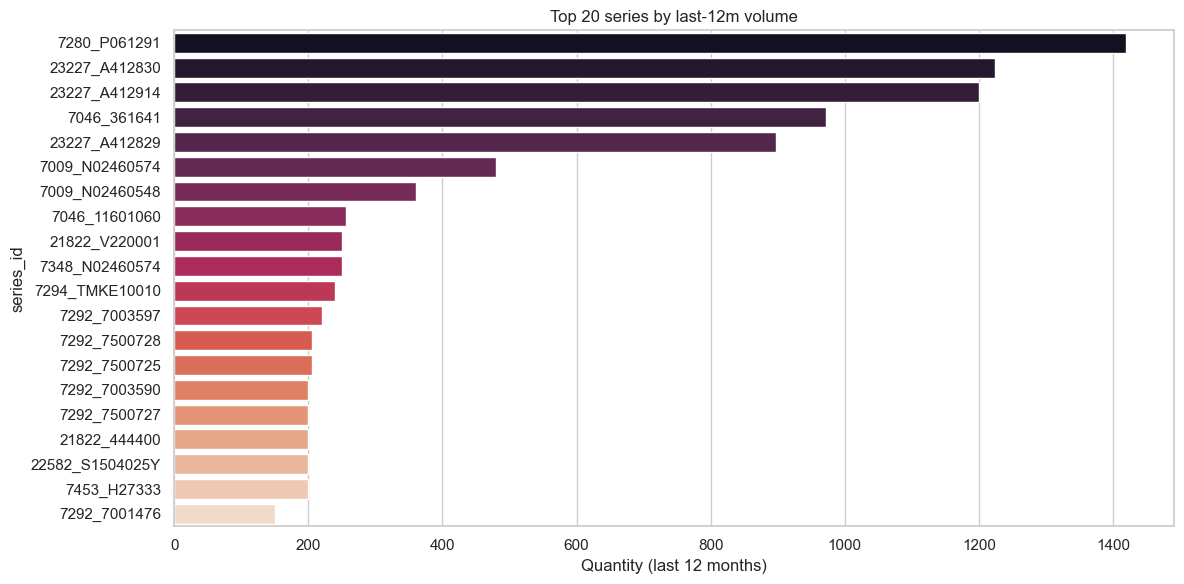

In [6]:

# Build / load series summary
if summary_v2 is not None:
    series_summary = summary_v2.copy()
else:
    # compute simple trend flags from TFT q50
    def trend_label(group):
        s = group.sort_values('Date')['q50']
        return trend_from_series(s, TREND_PCT_THRESHOLD, TREND_MIN_MEAN)

    trend_tft = tft_top.groupby('series_id').apply(trend_label).rename('trend_flag').reset_index()
    series_summary = top_series.merge(trend_tft, on='series_id', how='left')
    series_summary['trend_flag'] = series_summary['trend_flag'].fillna('stable')

# ---- Trend distribution ----
plt.figure(figsize=(8,4))
order = ['decreasing','stable','increasing']
vc = series_summary['trend_flag'].value_counts().reindex(order).fillna(0)
sns.barplot(x=vc.index, y=vc.values, palette='viridis')
plt.title('Trend distribution (TOP series)')
plt.ylabel('Number of series')
plt.xlabel('Trend flag')
plt.show()

# ---- Total forecast by month (sum of q50) ----
monthly = (tft_top.groupby('Date', as_index=False)
           .agg(total_q50=('q50','sum'), total_q10=('q10','sum') if 'q10' in tft_top.columns else ('q50','sum'),
                total_q90=('q90','sum') if 'q90' in tft_top.columns else ('q50','sum')))

plt.figure(figsize=(12,5))
plt.plot(monthly['Date'], monthly['total_q50'], marker='o', label='Total forecast (q50)')
if 'q10' in tft_top.columns and 'q90' in tft_top.columns:
    plt.fill_between(monthly['Date'], monthly['total_q10'], monthly['total_q90'], alpha=0.2, label='Approx band (sum q10–q90)')
plt.title('TOP series: Total forecast by month')
plt.xlabel('Month')
plt.ylabel('Forecast quantity')
plt.legend()
plt.show()

# ---- Top contributors by hist_revenue ----
top_rev = series_summary.sort_values('hist_revenue', ascending=False).head(SHOW_TOP_N)
plt.figure(figsize=(12,6))
sns.barplot(data=top_rev, y='series_id', x='hist_revenue', palette='mako')
plt.title(f'Top {SHOW_TOP_N} series by last-12m revenue')
plt.xlabel('Revenue (last 12 months)')
plt.ylabel('series_id')
plt.tight_layout()
plt.show()

# ---- Top contributors by hist_qty ----
top_qty = series_summary.sort_values('hist_qty', ascending=False).head(SHOW_TOP_N)
plt.figure(figsize=(12,6))
sns.barplot(data=top_qty, y='series_id', x='hist_qty', palette='rocket')
plt.title(f'Top {SHOW_TOP_N} series by last-12m volume')
plt.xlabel('Quantity (last 12 months)')
plt.ylabel('series_id')
plt.tight_layout()
plt.show()


## 6) Baseline performance dashboards (LightGBM)

If `y_qty` exists in your LightGBM file, we compute:
- MAE distribution
- WAPE distribution
- Error vs business impact (revenue)


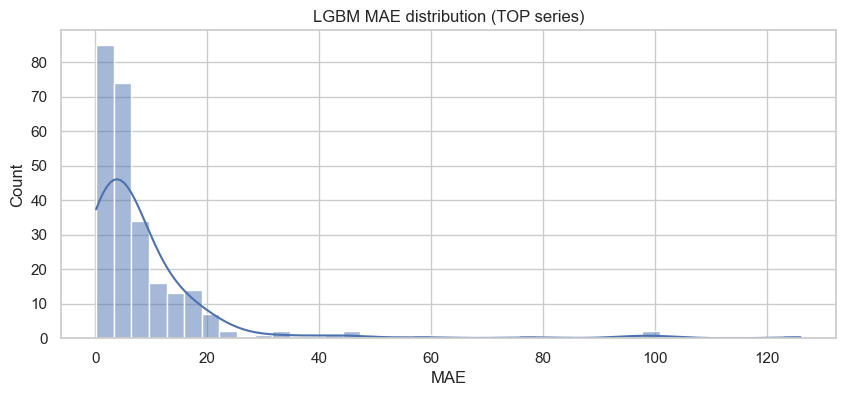

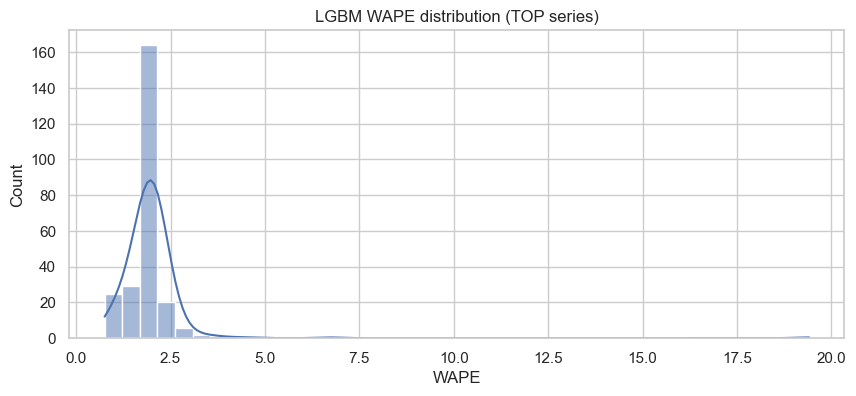

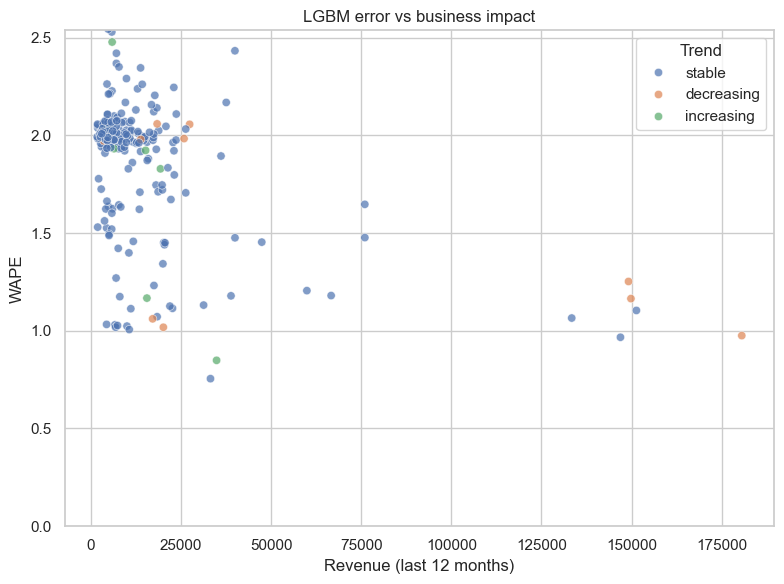

Top 10 worst WAPE series:


,series_id,mae,wape_num,wape_den,wape,hist_revenue,hist_qty,trend_flag
213,7417_304361,1.617523,19.410279,1.0,19.410279,4559.88,18.0,stable
246,7437_23471-2454,7.817497,93.809968,14.0,6.700712,113839.16,14.0,stable
211,7417_304352,9.174396,110.092749,24.0,4.587198,72244.56,24.0,stable
214,7417_304362,0.627142,7.525700,2.0,3.762850,4473.44,6.0,stable
73,5663_MM0391849,0.580722,6.968660,2.0,3.484330,6835.78,2.0,stable
106,7120_146630,5.688819,68.265829,20.0,3.413291,3214.00,50.0,stable
55,23227_A43086,2.485491,29.825895,10.0,2.982589,2953.80,20.0,stable
115,7194_50047174,4.856166,58.273989,20.0,2.913699,3257.20,40.0,stable
249,7437_EW33,4.625960,55.511517,20.0,2.775576,44126.40,20.0,stable
92,7031_F657106,13.522289,162.267464,60.0,2.704458,13315.84,101.0,stable


In [7]:

if lgbm_top is None or 'y_qty' not in lgbm_top.columns:
    print("No LGBM actuals found (y_qty). Skipping error dashboards.")
else:
    df = lgbm_top.copy()
    df['abs_error'] = (df['forecast_qty'] - df['y_qty']).abs()

    per = df.groupby('series_id', as_index=False).agg(
        mae=('abs_error','mean'),
        wape_num=('abs_error','sum'),
        wape_den=('y_qty','sum')
    )
    per['wape'] = per['wape_num'] / per['wape_den'].replace({0: np.nan})

    # Join revenue impact
    per = per.merge(series_summary[['series_id','hist_revenue','hist_qty','trend_flag']], on='series_id', how='left')

    plt.figure(figsize=(10,4))
    sns.histplot(per['mae'].replace([np.inf,-np.inf],np.nan).dropna(), bins=40, kde=True)
    plt.title('LGBM MAE distribution (TOP series)')
    plt.xlabel('MAE')
    plt.show()

    plt.figure(figsize=(10,4))
    sns.histplot(per['wape'].replace([np.inf,-np.inf],np.nan).dropna(), bins=40, kde=True)
    plt.title('LGBM WAPE distribution (TOP series)')
    plt.xlabel('WAPE')
    plt.show()

    plt.figure(figsize=(8,6))
    sns.scatterplot(data=per, x='hist_revenue', y='wape', hue='trend_flag', alpha=0.7)
    plt.title('LGBM error vs business impact')
    plt.xlabel('Revenue (last 12 months)')
    plt.ylabel('WAPE')
    plt.ylim(0, np.nanpercentile(per['wape'], 95))
    plt.legend(title='Trend')
    plt.tight_layout()
    plt.show()

    print("Top 10 worst WAPE series:")
    display(per.sort_values('wape', ascending=False).head(10))


## 7) Per-series deep dive

This is the most useful visualization for business review:
- last 24–36 months of history
- forecast horizon with uncertainty band (q10–q90)
- trend flag
- baseline validation plot (if LGBM actuals exist)


In [8]:

def plot_series(series_id: str, history_months: int = 36):
    # --- history ---
    h = hist[hist['series_id'] == series_id].sort_values('Date').copy()
    if h.empty:
        print('No history for', series_id)
        return

    last_hist_date = h['Date'].max()
    hist_start = last_hist_date - pd.DateOffset(months=history_months-1)
    h = h[h['Date'] >= hist_start]

    # --- forecast ---
    f = tft_top[tft_top['series_id'] == series_id].sort_values('Date').copy()

    # --- meta (keep both DF + dict safely) ---
    meta_row = series_summary[series_summary['series_id'] == series_id].head(1)
    meta_dict = meta_row.iloc[0].to_dict() if not meta_row.empty else {}

    title = series_id
    if meta_dict:
        title = f"{series_id} | {meta_dict.get('customer_name','')} | {meta_dict.get('product_name','')} | Trend: {meta_dict.get('trend_flag','')}"

    # --- Plot 1: history + TFT ---
    plt.figure(figsize=(14,6))
    plt.plot(h['Date'], h['ordered_qty'], marker='o', label='History (ordered_qty)')

    if not f.empty:
        plt.plot(f['Date'], f['q50'], marker='o', label='TFT forecast (q50)')
        if 'q10' in f.columns and 'q90' in f.columns:
            plt.fill_between(f['Date'], f['q10'], f['q90'], alpha=0.2, label='TFT band (q10–q90)')
        plt.axvline(forecast_start, color='black', linestyle='--', alpha=0.6, label='Forecast start')

    plt.title(title)
    plt.xlabel('Month')
    plt.ylabel('Quantity')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- Plot 2: LGBM validation (optional) ---
    if lgbm_top is not None and series_id in set(lgbm_top['series_id']) and 'forecast_qty' in lgbm_top.columns:
        g = lgbm_top[lgbm_top['series_id'] == series_id].sort_values('Date').copy()
        if 'y_qty' in g.columns:
            plt.figure(figsize=(14,5))
            plt.plot(g['Date'], g['y_qty'], marker='o', label='Actual (y_qty)')
            plt.plot(g['Date'], g['forecast_qty'], marker='o', label='LGBM forecast')
            plt.title(f"LGBM validation | {series_id}")
            plt.xlabel('Month')
            plt.ylabel('Quantity')
            plt.legend()
            plt.tight_layout()
            plt.show()

            g['abs_error'] = (g['forecast_qty'] - g['y_qty']).abs()
            mae = g['abs_error'].mean()
            den = g['y_qty'].sum()
            wape = g['abs_error'].sum() / den if den != 0 else np.nan
            print(f"LGBM MAE: {mae:.4f} | LGBM WAPE: {wape:.4f}")

    # --- Print meta summary ---
    if meta_dict:
        keep = ['hist_revenue','hist_qty','rev_rank','qty_rank','trend_flag']
        print('Series summary:')
        print({k: meta_dict.get(k) for k in keep if k in meta_dict})


examples = series_summary.sort_values('hist_revenue', ascending=False).head(5)['series_id'].tolist()
examples


['23227_A412830',
 '7046_361641',
 '23227_A412829',
 '7294_TMKE10396',
 '23227_A412914']

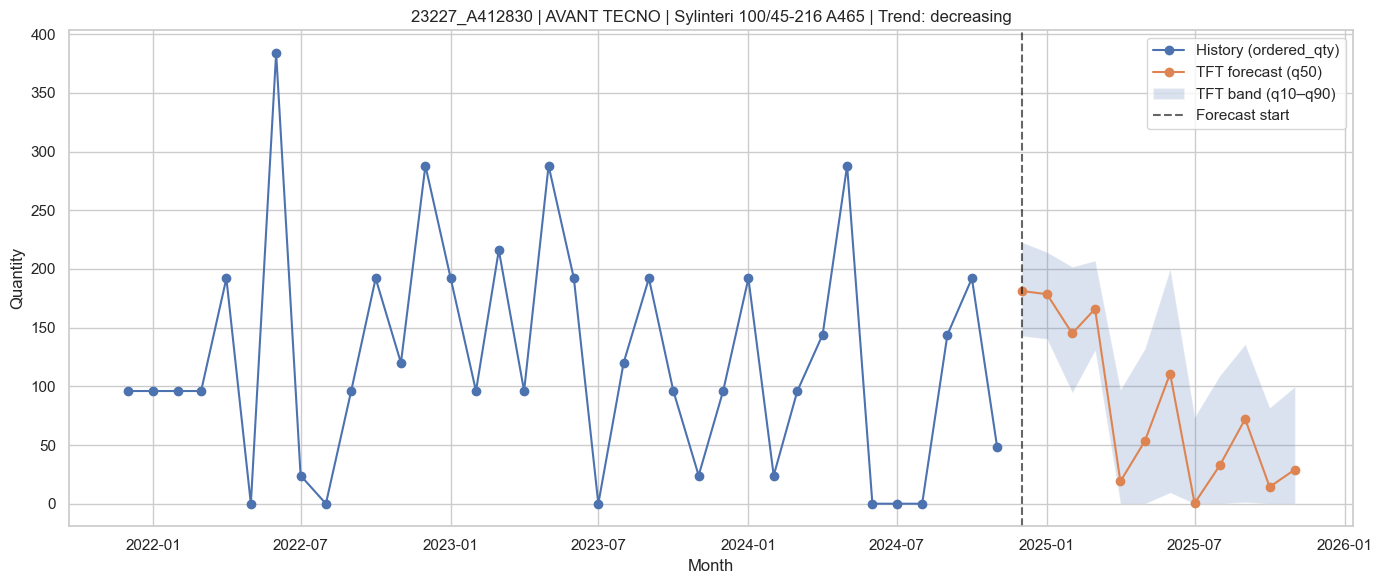

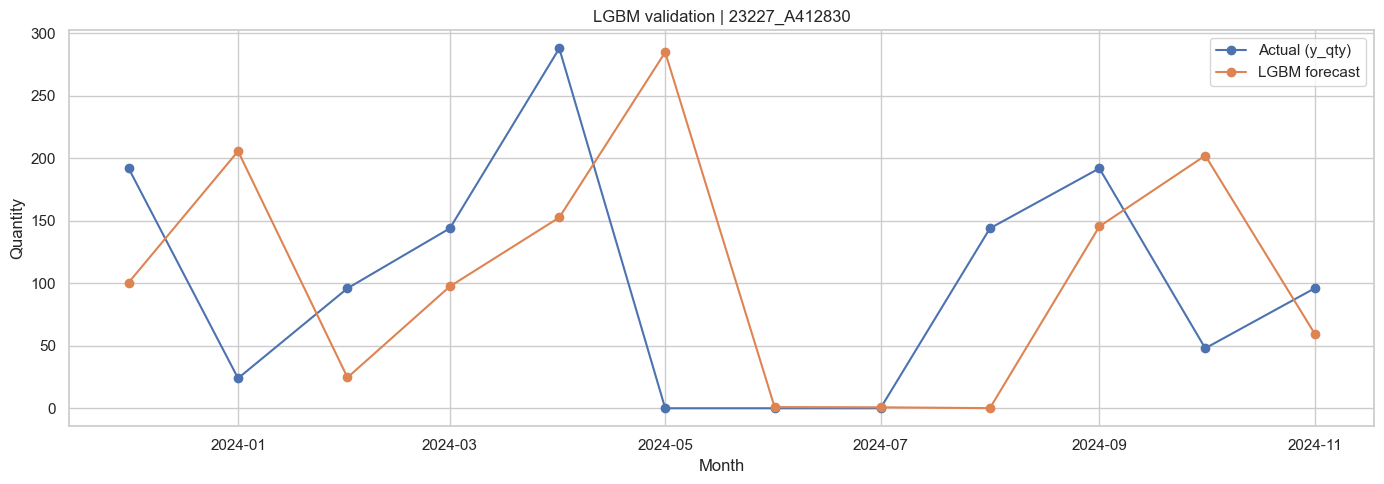

LGBM MAE: 99.4945 | LGBM WAPE: 0.9754
Series summary:
{'hist_revenue': 180571.44, 'hist_qty': 1224.0, 'rev_rank': 1.0, 'qty_rank': 2.0, 'trend_flag': 'decreasing'}


In [9]:

# Example: plot the top revenue series
plot_series(examples[0], history_months=36)


## 8) Quick slice: show predictions for a chosen series

Change `SERIES_ID` below to inspect any customer-product.


In [10]:

SERIES_ID = examples[0]  # <-- change this

# Show TFT forecast rows
display(tft_top[tft_top['series_id']==SERIES_ID].sort_values('Date').head(20))

# Show last 24 months of history
display(hist[hist['series_id']==SERIES_ID].sort_values('Date').tail(24))


,series_id,Date,time_idx,h,q02,q10,q25,q50,q75,q90,q98,Year,Month
53,23227_A412830,2024-12-01,119,1,1.216392e+02,1.429522e+02,1.606269e+02,181.195920,202.598050,222.851470,264.61404,2024,12
310,23227_A412830,2025-01-01,120,2,1.263042e+02,1.404046e+02,1.630852e+02,178.509860,196.564240,214.391900,250.73407,2025,1
567,23227_A412830,2025-02-01,121,3,7.139410e+01,9.468559e+01,1.236631e+02,145.026860,172.760280,201.830440,249.69125,2025,2
824,23227_A412830,2025-03-01,122,4,1.143578e+02,1.307027e+02,1.552733e+02,165.991870,183.086000,207.011440,257.17413,2025,3
1081,23227_A412830,2025-04-01,123,5,0.000000e+00,4.466762e-27,1.191896e-07,18.943977,57.582540,97.247440,160.13278,2025,4
1338,23227_A412830,2025-05-01,124,6,5.836860e-40,5.395756e-13,1.737063e+01,53.302000,92.227870,132.106930,200.75084,2025,5
1595,23227_A412830,2025-06-01,125,7,5.375326e-24,9.479126e+00,6.760642e+01,110.800390,156.966810,200.103550,281.19104,2025,6
1852,23227_A412830,2025-07-01,126,8,0.000000e+00,1.978033e-36,2.326184e-18,0.430152,37.570827,74.015564,157.84883,2025,7
2109,23227_A412830,2025-08-01,127,9,0.000000e+00,1.473362e-22,7.443655e-04,32.734222,70.600310,109.340210,186.03876,2025,8
2366,23227_A412830,2025-09-01,128,10,1.734333e-19,1.309466e+00,3.724166e+01,72.126480,104.895980,135.910700,206.24393,2025,9


,customer_id,product_id,customer_name,product_group,product_name,Date,ordered_qty,order_amount,series_id
319134,23227,A412830,AVANT TECNO,5002,Sylinteri 100/45-216 A465,2022-12-01,288.0,41912.64,23227_A412830
319135,23227,A412830,AVANT TECNO,5002,Sylinteri 100/45-216 A465,2023-01-01,192.0,27941.76,23227_A412830
319136,23227,A412830,AVANT TECNO,5002,Sylinteri 100/45-216 A465,2023-02-01,96.0,13970.88,23227_A412830
319137,23227,A412830,AVANT TECNO,5002,Sylinteri 100/45-216 A465,2023-03-01,216.0,31783.44,23227_A412830
319138,23227,A412830,AVANT TECNO,5002,Sylinteri 100/45-216 A465,2023-04-01,96.0,13970.88,23227_A412830
319139,23227,A412830,AVANT TECNO,5002,Sylinteri 100/45-216 A465,2023-05-01,288.0,41912.64,23227_A412830
319140,23227,A412830,AVANT TECNO,5002,Sylinteri 100/45-216 A465,2023-06-01,192.0,27941.76,23227_A412830
319141,23227,A412830,AVANT TECNO,5002,Sylinteri 100/45-216 A465,2023-07-01,0.0,0.00,23227_A412830
319142,23227,A412830,AVANT TECNO,5002,Sylinteri 100/45-216 A465,2023-08-01,120.0,17812.56,23227_A412830
319143,23227,A412830,AVANT TECNO,5002,Sylinteri 100/45-216 A465,2023-09-01,192.0,27941.76,23227_A412830


## 9) Optional: seasonality view (portfolio)

Average forecast by month-of-year across TOP series.


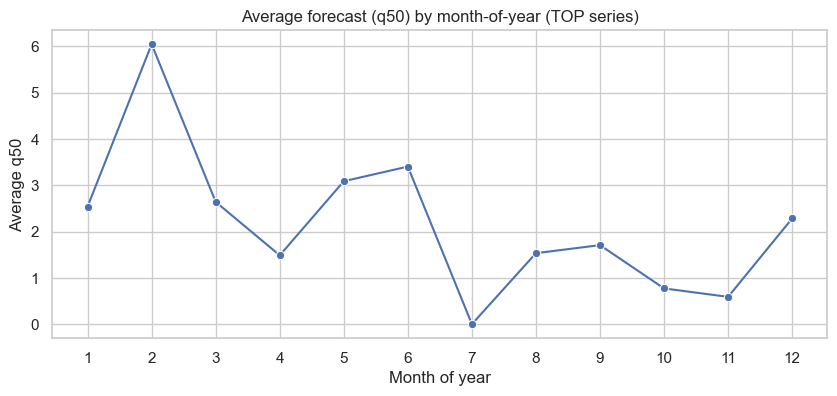

In [11]:

# month-of-year seasonality using TFT q50
season = tft_top.copy()
season['month_of_year'] = season['Date'].dt.month
seasonal = season.groupby('month_of_year', as_index=False).agg(avg_q50=('q50','mean'))

plt.figure(figsize=(10,4))
sns.lineplot(data=seasonal, x='month_of_year', y='avg_q50', marker='o')
plt.title('Average forecast (q50) by month-of-year (TOP series)')
plt.xlabel('Month of year')
plt.ylabel('Average q50')
plt.xticks(range(1,13))
plt.show()


## 10) Export plots (optional)

You can save any figure by calling `plt.savefig('name.png', dpi=200, bbox_inches='tight')` right before `plt.show()`.
